$$ ITI \space AI-Pro: \space Intake \space 45 $$
$$ Machine \space Learning \space 1 $$
$$ Lab \space no. \space 2 $$

# `01` Import Necessary Libraries

## `i` Default Libraries

In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

## `ii` Additional Libraries
Add imports for additional libraries you used throughout the notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler


----------------------------

# `02` Load Data

In [3]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

## `#` Create Test Set

Before exploring the data, let's split the data into training and test sets. You shouldn't touch the test set from this point furthur except for final model evaluation.

Use:
- `random_state` $= 1234$
- `test_size` $= 0.2$

Hint: You can use `sklearn.model_selection.train_test_split` function

In [4]:

train_set, temp_set = train_test_split(housing, test_size=0.2, random_state=1234)
val_set,test_set=train_test_split(temp_set, test_size=0.5, random_state=1234)

In [5]:
train_set.shape

(16512, 10)

In [6]:
val_set.shape

(2064, 10)

In [7]:
test_set.shape

(2064, 10)

----------------

# `03` Exploratory Data Analysis (EDA)

## `i` Simple Analysis

Preview data, perform statistical data analysis and explore as much as needed to better understand the data set we're dealing with.

`Note:` Feel free to look up EDA approaches online for inspiration (however you **must understand** everything and not copy paste).

In [8]:
train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
17595,-120.07,36.98,12.0,1790.0,379.0,1399.0,397.0,2.5388,59600.0,INLAND
6073,-118.22,33.86,16.0,8732.0,1489.0,3944.0,1493.0,5.1948,203500.0,<1H OCEAN
6251,-120.94,39.32,14.0,3120.0,595.0,1569.0,556.0,3.5385,157400.0,INLAND
3161,-122.11,37.68,37.0,1976.0,481.0,1197.0,465.0,2.5772,170200.0,NEAR BAY
1887,-121.34,38.67,35.0,643.0,117.0,331.0,134.0,3.0417,120700.0,INLAND


In [9]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 17595 to 1318
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16354 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.4+ MB


In [10]:
train_set.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,158
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


# there are missing values in total_bedrooms , solving it in data prepration

In [11]:
train_set.duplicated().sum()  # there no duplicate in the dataset

0

In [12]:
train_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16354.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.576297,35.640944,28.629300,2634.395652,537.400086,1422.226562,499.014595,3.869583,207185.675327
std,2.008301,2.141025,12.622547,2195.367194,422.272540,1119.964665,383.148507,1.896395,115624.027082
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.802500,33.930000,18.000000,1452.750000,296.000000,786.000000,280.000000,2.562500,119800.000000
50%,-118.500000,34.260000,29.000000,2128.000000,435.000000,1166.000000,410.000000,3.539400,180400.000000
75%,-118.010000,37.720000,37.000000,3138.250000,646.000000,1720.000000,603.000000,4.748350,265600.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,28566.000000,6082.000000,15.000100,500001.000000


## `ii` Visual Analysis

Plot graphs and relations in order to gain more insights about the data set, identify patterns, and make assumptions.

`Note:` Feel free to look up visual EDA approaches online for inspiration (however you **must understand** everything and not copy paste).

In [13]:
train_set.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

<Axes: xlabel='housing_median_age', ylabel='Count'>

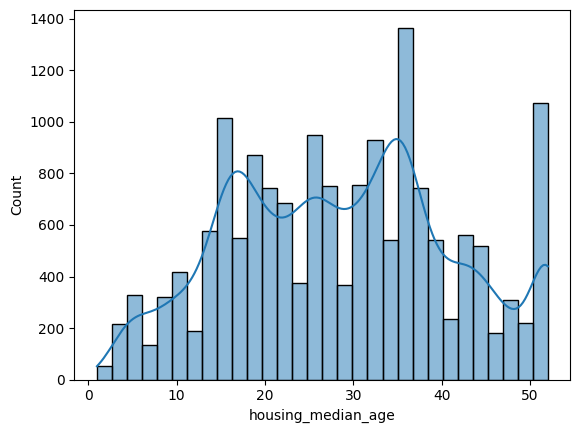

In [14]:
sns.histplot(data=train_set, x='housing_median_age', bins=30,kde=True)

# most houses' ages in range 20,40

<Axes: xlabel='housing_median_age', ylabel='median_house_value'>

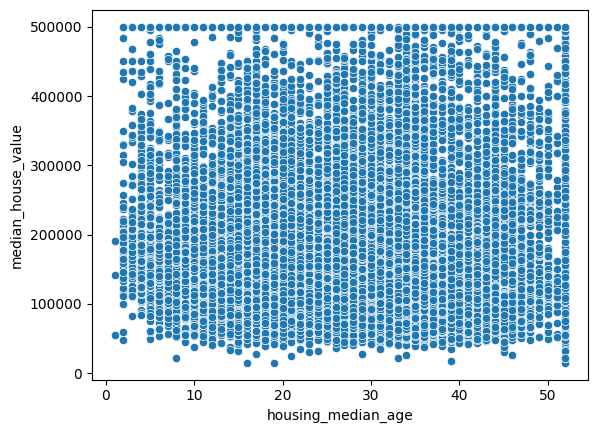

In [15]:
sns.scatterplot(data=train_set, x='housing_median_age', y='median_house_value')

<Axes: xlabel='total_rooms', ylabel='total_bedrooms'>

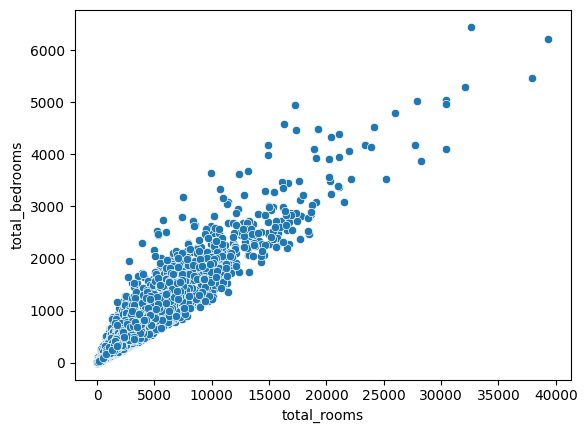

In [16]:
sns.scatterplot(data=train_set, x='total_rooms', y='total_bedrooms')

# there is strong relation between total rooms and total numbers of bedrooms

<Axes: xlabel='households', ylabel='population'>

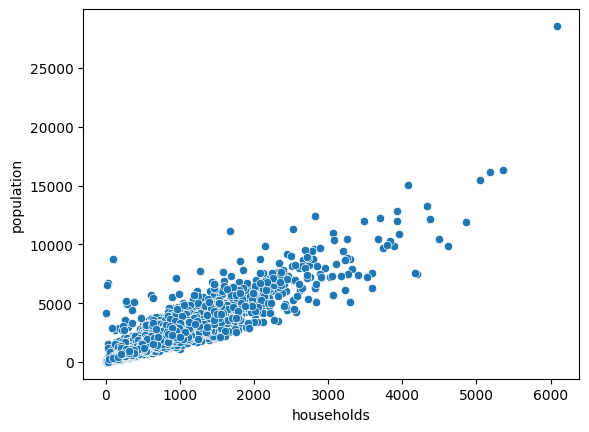

In [17]:
sns.scatterplot(data=train_set, x='households', y='population')

# the more  households the more of population

<Axes: xlabel='ocean_proximity', ylabel='count'>

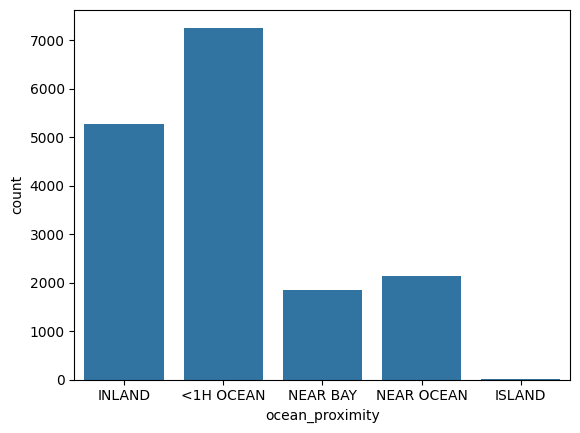

In [18]:
sns.countplot(data=train_set,x=train_set['ocean_proximity'])

<Axes: xlabel='ocean_proximity', ylabel='population'>

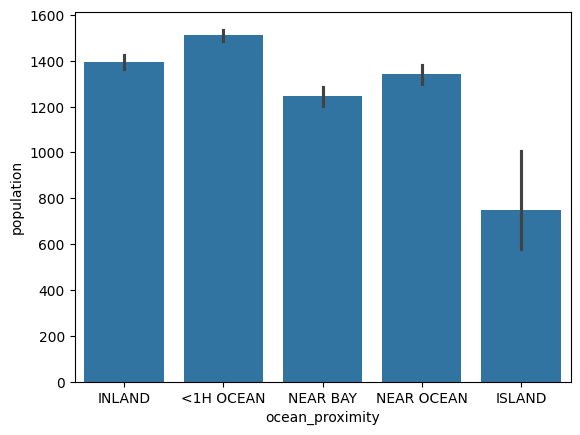

In [19]:
sns.barplot(data=train_set, x='ocean_proximity', y='population')

# the most population in places that are <1H ocean

<Axes: xlabel='ocean_proximity', ylabel='households'>

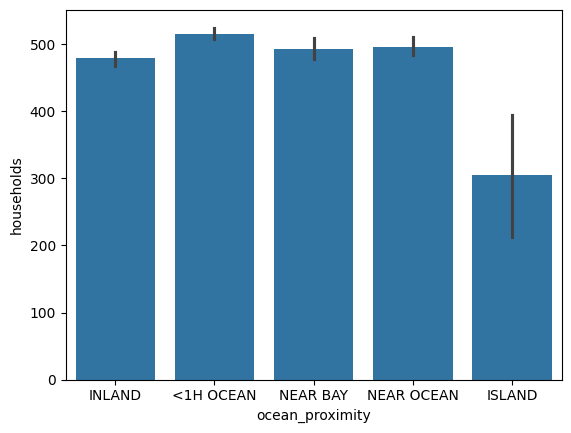

In [20]:
sns.barplot(data=train_set, x='ocean_proximity', y='households')

# the most households in places that are <1H ocean

<Axes: xlabel='ocean_proximity', ylabel='median_income'>

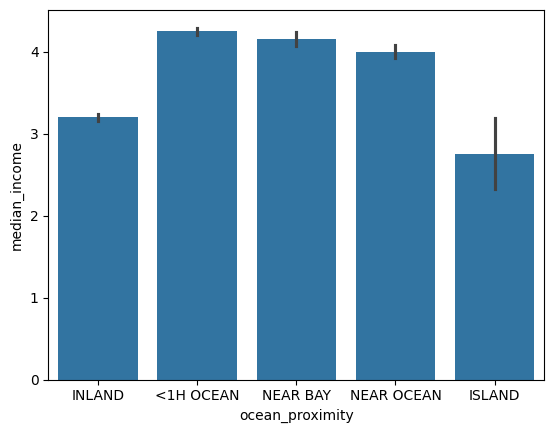

In [21]:
sns.barplot(data=train_set, x='ocean_proximity', y='median_income')

# People with high median income live <1H ocean

<Axes: xlabel='median_income', ylabel='total_rooms'>

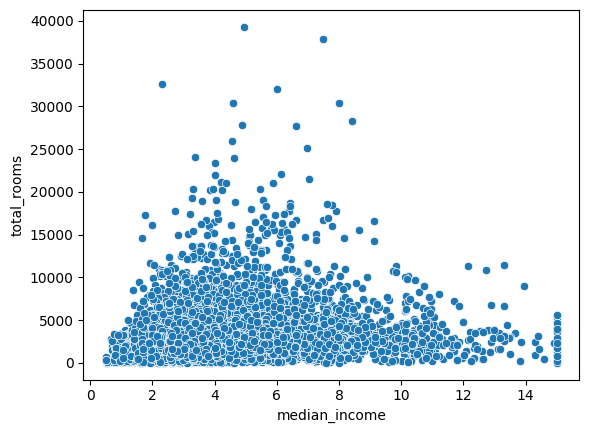

In [22]:
sns.scatterplot(data=train_set, y='total_rooms', x='median_income')

<Axes: xlabel='population', ylabel='total_rooms'>

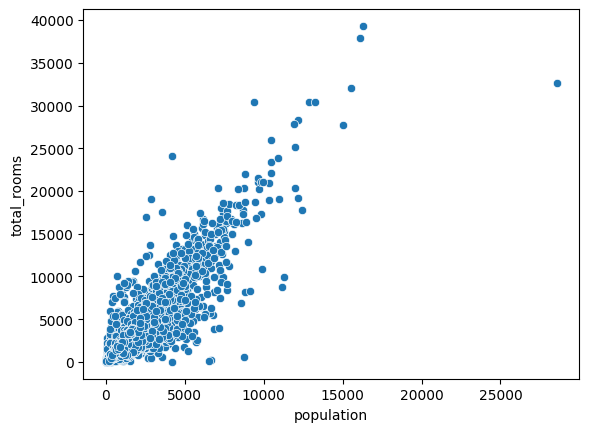

In [23]:
sns.scatterplot(data=train_set, y='total_rooms', x='population')

<Axes: xlabel='median_house_value', ylabel='Count'>

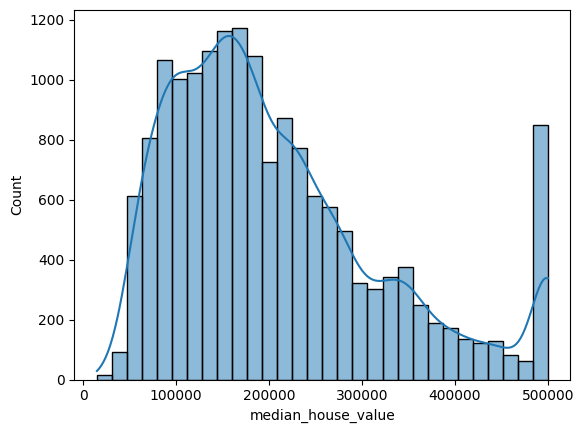

In [24]:
sns.histplot(data=train_set, x='median_house_value', bins=30,kde=True)

# the most median house value between 10000 and 300000

<Axes: xlabel='median_house_value', ylabel='total_rooms'>

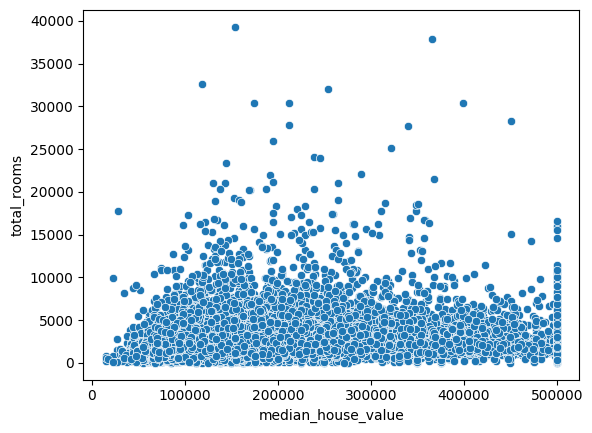

In [25]:
sns.scatterplot(data=train_set, y='total_rooms', x='median_house_value')

# the total number of rooms don't affect medain house value

<Axes: xlabel='median_house_value', ylabel='population'>

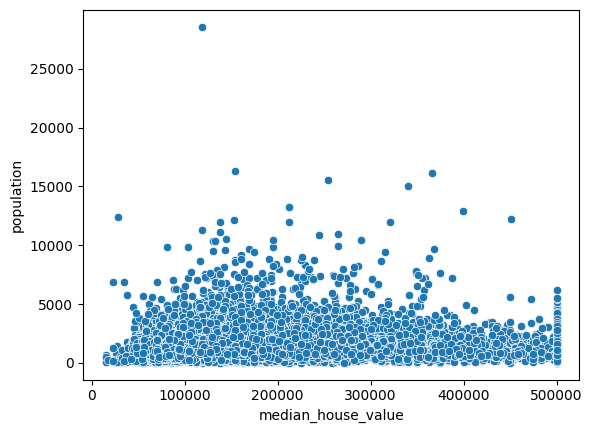

In [26]:
sns.scatterplot(data=train_set, y='population', x='median_house_value')

# the most median house value in free population

<Axes: xlabel='median_house_value', ylabel='households'>

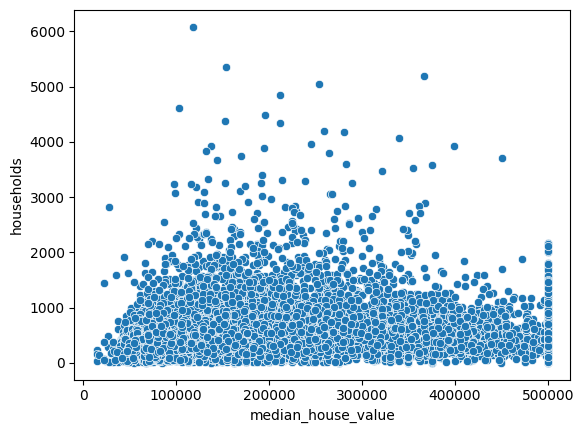

In [27]:
sns.scatterplot(data=train_set, y='households', x='median_house_value')

<Axes: xlabel='median_income', ylabel='median_house_value'>

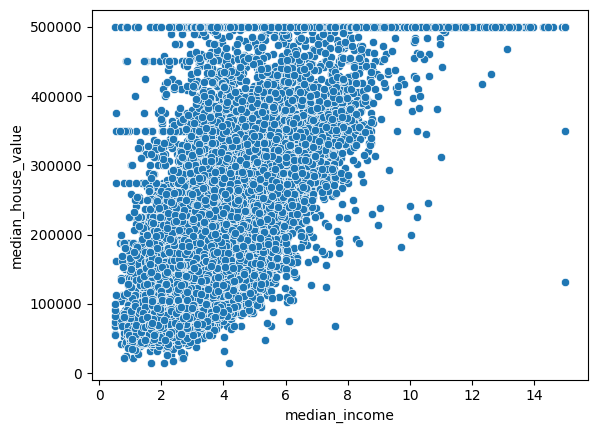

In [28]:
sns.scatterplot(data=train_set, x='median_income', y='median_house_value')

# Areas with higher median incomes are more likely to have higher house values

<Axes: xlabel='ocean_proximity', ylabel='median_house_value'>

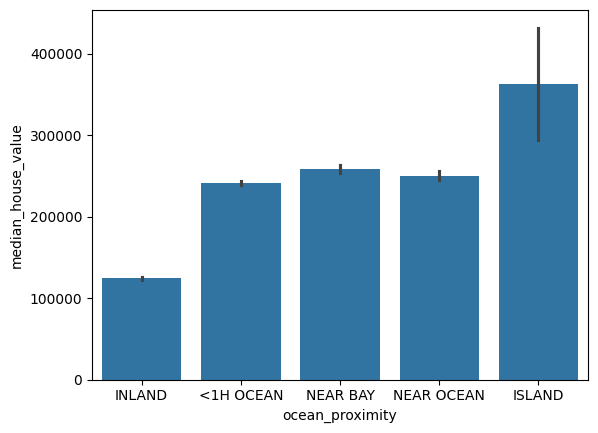

In [29]:
sns.barplot(data=train_set, x='ocean_proximity', y='median_house_value')

# the median house value increase in ISland

longitude


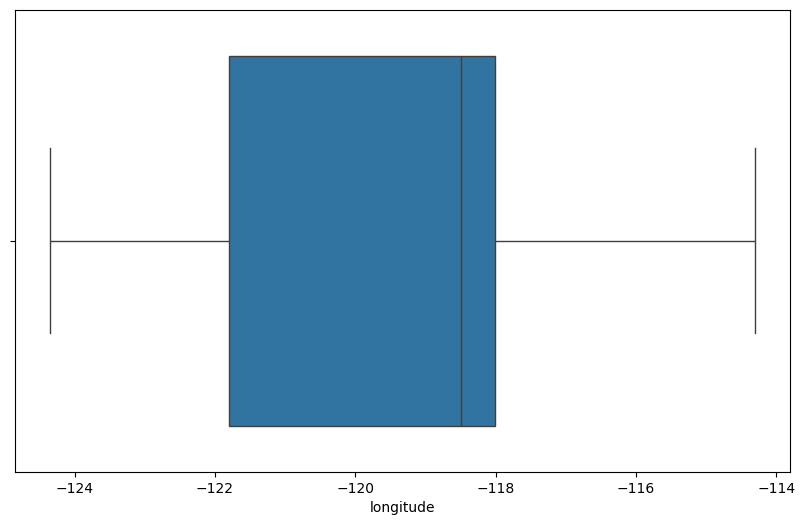

latitude


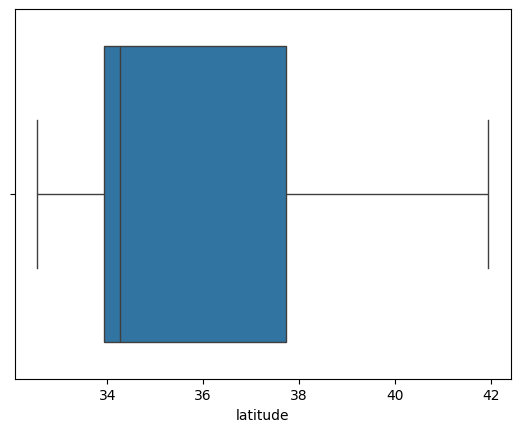

housing_median_age


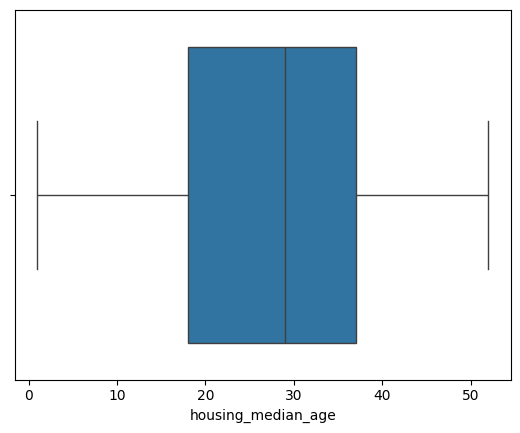

total_rooms


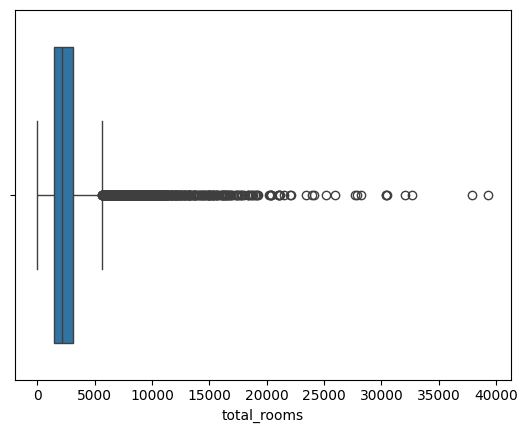

total_bedrooms


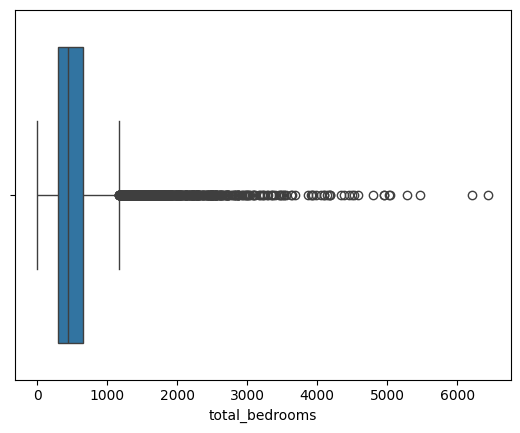

population


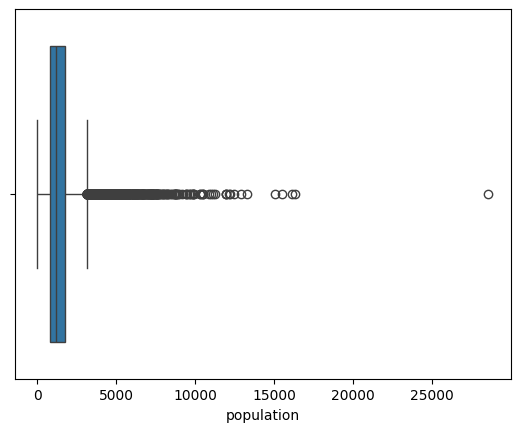

households


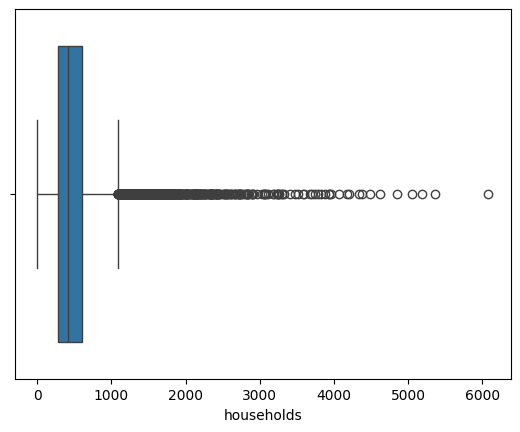

median_income


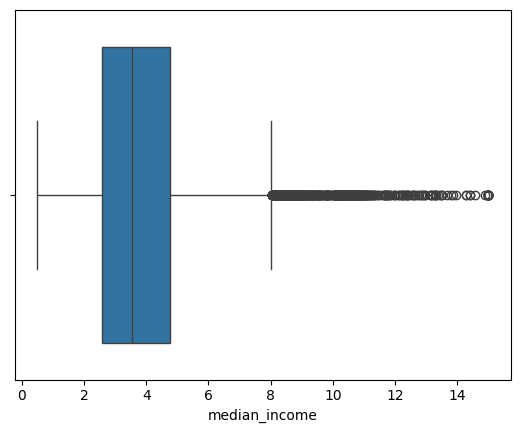

median_house_value


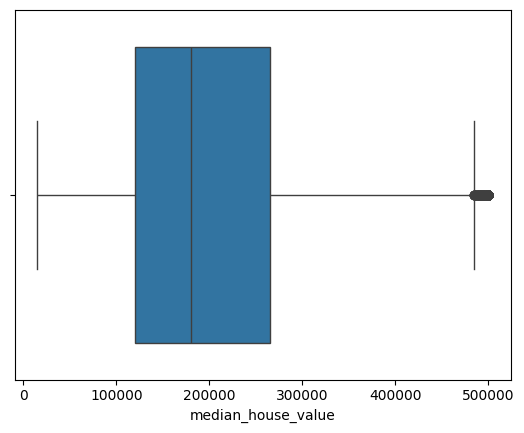

ocean_proximity


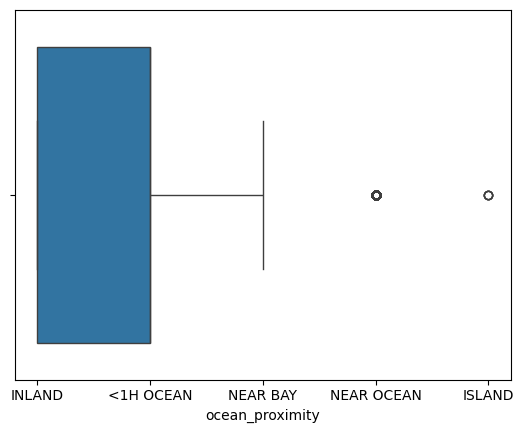

In [30]:
# check the outlier
plt.figure(figsize=(10, 6))
for col in train_set:
  print(col)
  sns.boxplot(data=train_set, x=col)
  plt.show()


In [31]:
def outlier_percentage_iqr(df):
    outlier_percentages = {}
    for column in df.select_dtypes(include=['number']):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
        outlier_percentages[column] = (outliers / len(df)) * 100
    return outlier_percentages

outlier_percentages = outlier_percentage_iqr(train_set)
outlier_percentages


{'longitude': 0.0,
 'latitude': 0.0,
 'housing_median_age': 0.0,
 'total_rooms': 6.268168604651163,
 'total_bedrooms': 6.031976744186047,
 'population': 5.765503875968992,
 'households': 5.880571705426356,
 'median_income': 3.3187984496124034,
 'median_house_value': 5.135658914728682}

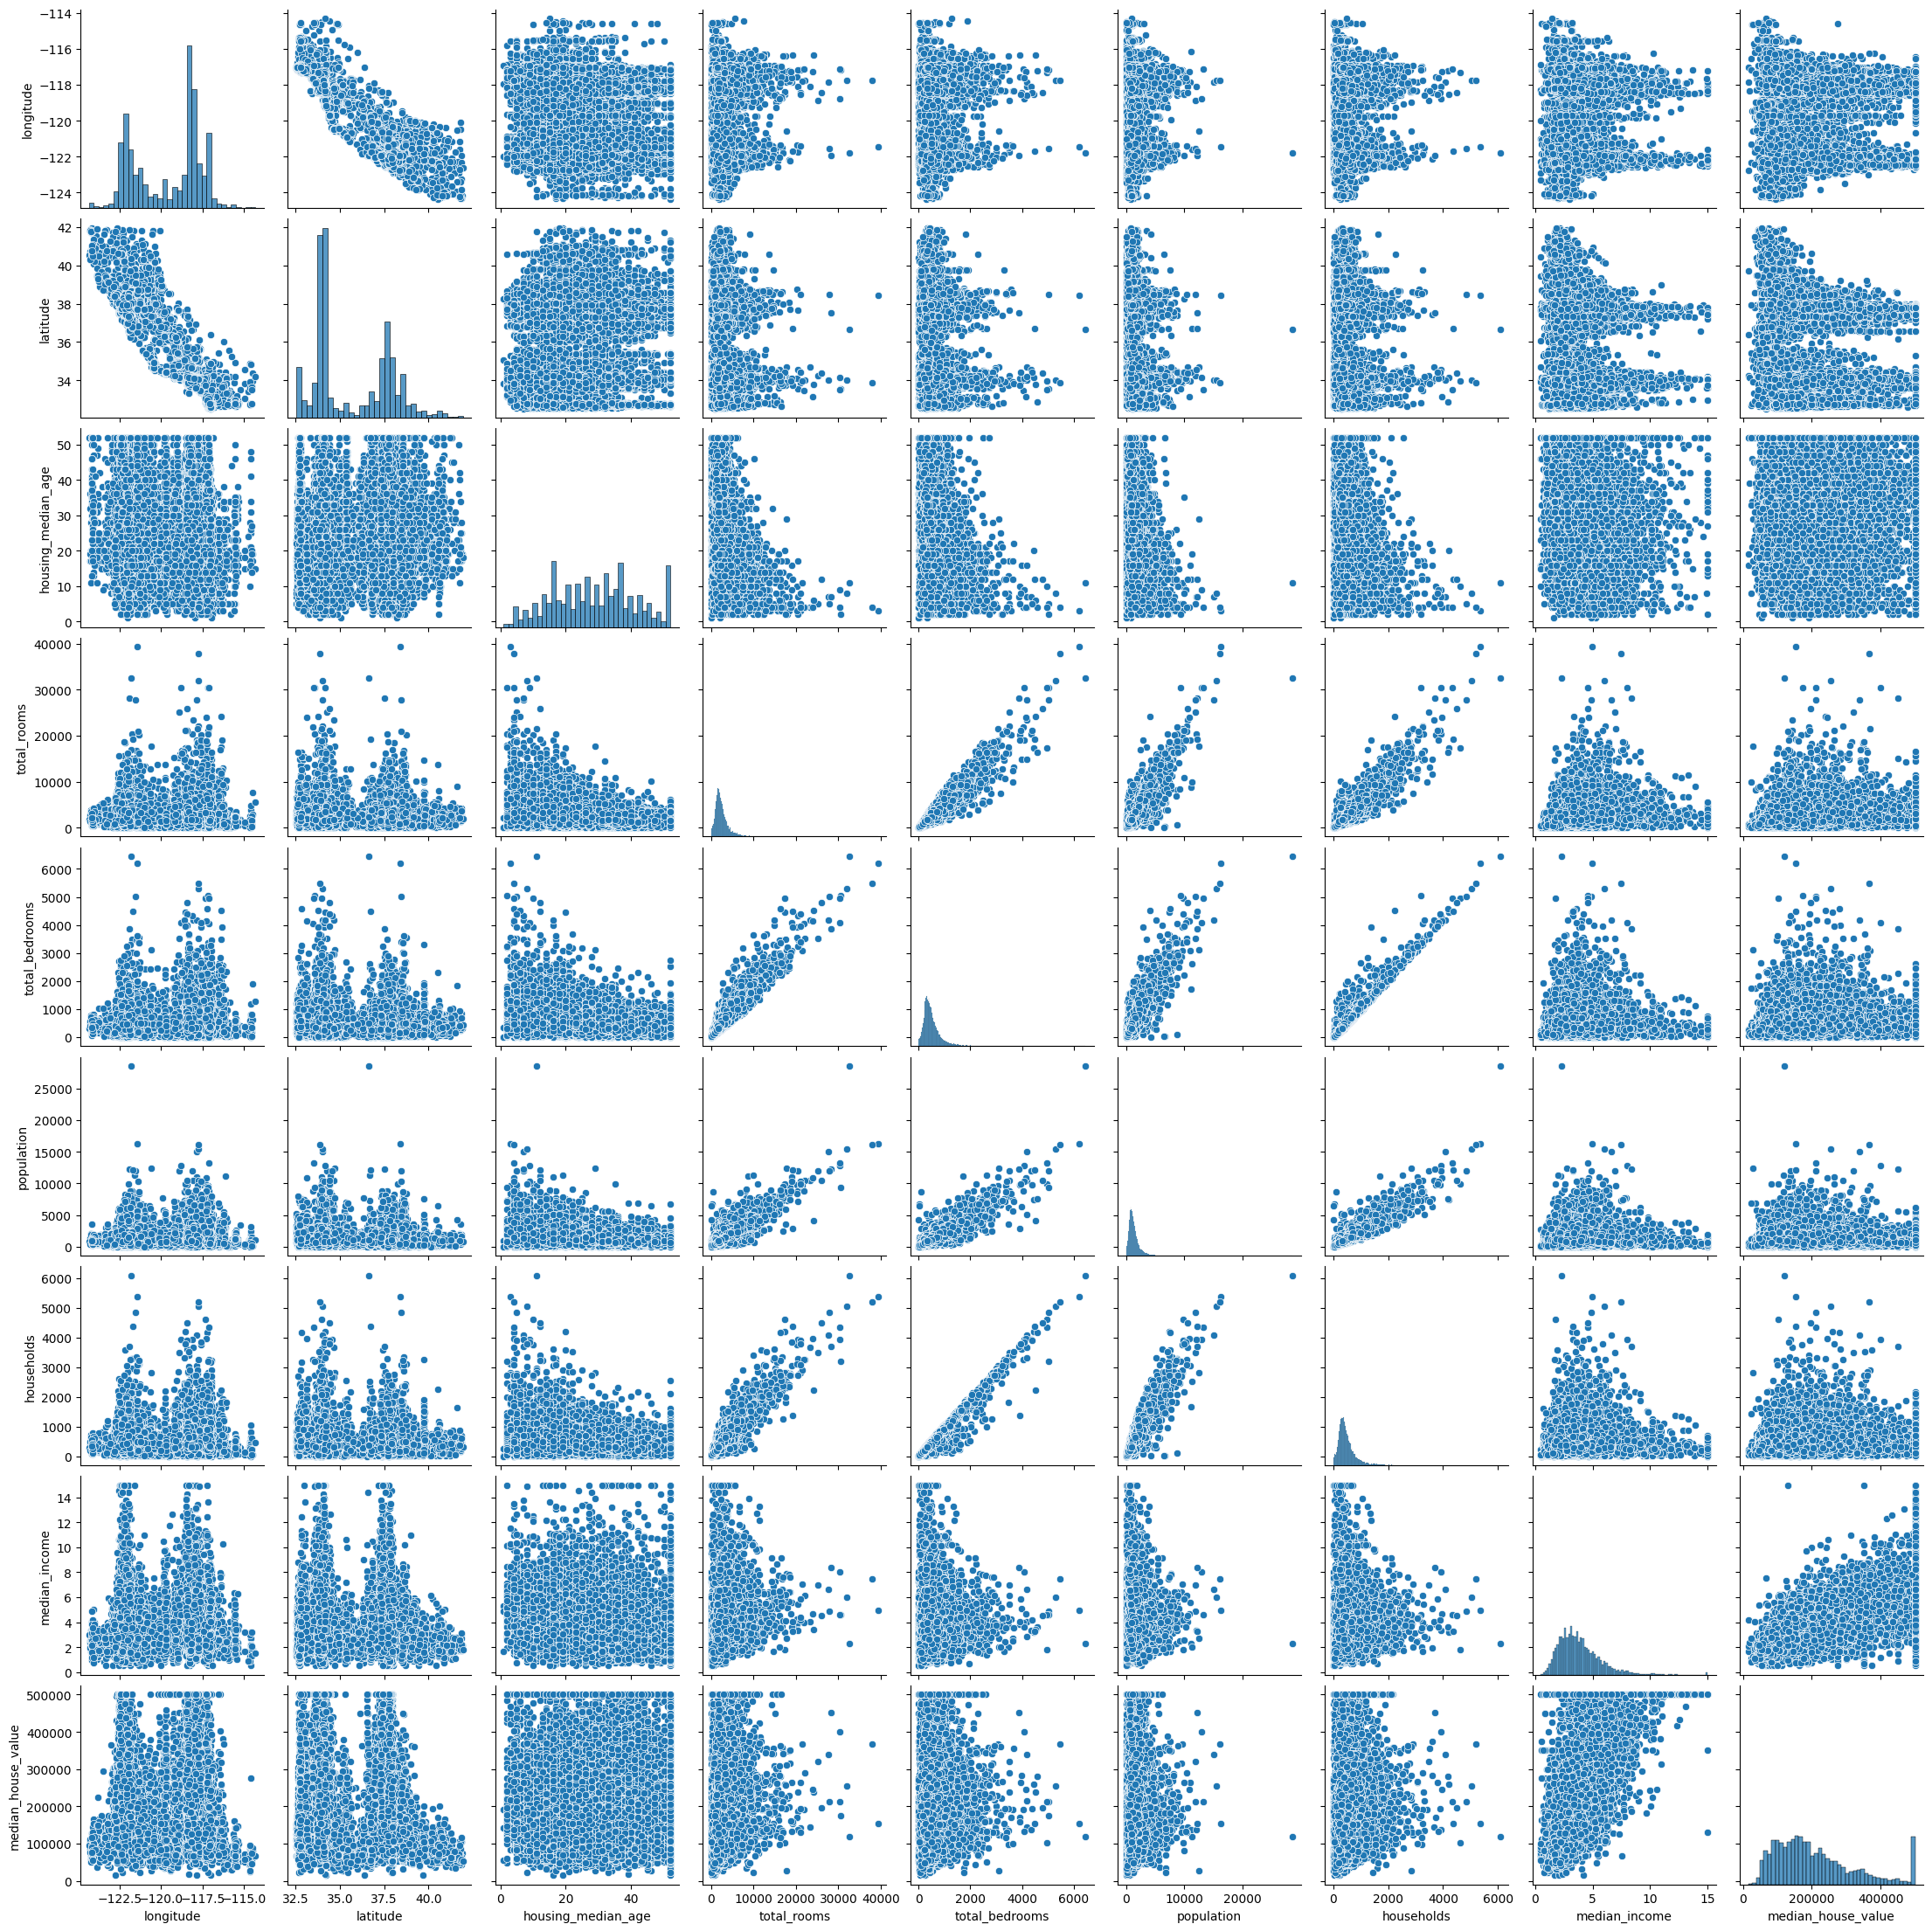

In [32]:
sns.pairplot(data=train_set)

----------------

# `04` Data Preparation

In [33]:
# remove missing values
train_set.dropna(subset=['total_bedrooms'], inplace=True)

In [34]:
train_set.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


#**Feature Selection**

<Axes: >

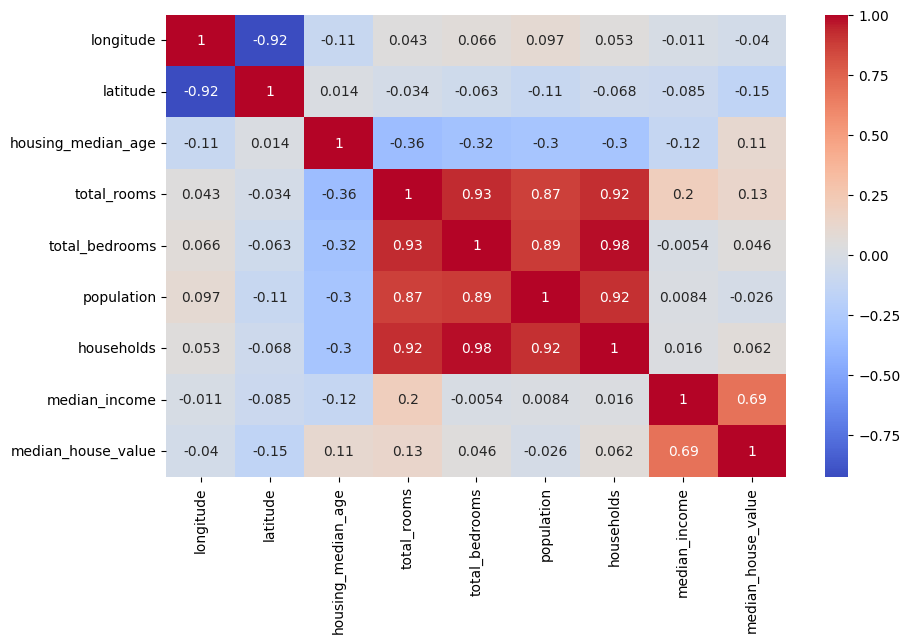

In [35]:
plt.figure(figsize=(10, 6))
sns.heatmap(train_set.select_dtypes('number').corr(), annot=True, cmap='coolwarm')

In [36]:
# label encoder
train_set['ocean_proximity'].replace({'NEAR BAY': 0, '<1H OCEAN': 1, 'INLAND': 2, 'NEAR OCEAN': 3, 'ISLAND': 4}, inplace=True)

<ipython-input-36-1fcea187574b>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_set['ocean_proximity'].replace({'NEAR BAY': 0, '<1H OCEAN': 1, 'INLAND': 2, 'NEAR OCEAN': 3, 'ISLAND': 4}, inplace=True)
<ipython-input-36-1fcea187574b>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_set['

In [37]:
train_set.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [38]:
features=train_set[['longitude','latitude','housing_median_age','median_income','ocean_proximity','total_rooms']]
target=train_set[['median_house_value']]

Perform data cleaning, feature engineering, scaling, etc. as needed to make sure it's ready for the model.

Hint: It could be helpful to check `sklearn.preprocessing` module.

In [39]:
# using RobustScaler to reduce the effect of outlier
scaler=RobustScaler()
scaled_features=scaler.fit_transform(features)

## `#` Prepare Test Set

Apply the data transformations you used on the training set to the test set.

**Important Note:** DO NOT use `fit` on the test set.

In [40]:
val_set.replace({'NEAR BAY': 0, '<1H OCEAN': 1, 'INLAND': 2, 'NEAR OCEAN': 3, 'ISLAND': 4}, inplace=True)


<ipython-input-40-e1764d644833>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  val_set.replace({'NEAR BAY': 0, '<1H OCEAN': 1, 'INLAND': 2, 'NEAR OCEAN': 3, 'ISLAND': 4}, inplace=True)


In [41]:
val_set.dropna(subset=['total_bedrooms'], inplace=True)

In [42]:
val_set.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [43]:
val_features=val_set[['longitude','latitude','housing_median_age','median_income','ocean_proximity','total_rooms']]
val_target=val_set[['median_house_value']]
scaled_val=scaler.transform(val_features)

----------------------------

# `05` Normal Equation

Using `sklearn` implementation of the linear regression closed-form solution, i.e. normal equation, to model the data.

Hint: Look for `sklearn.linear_model.LinearRegression` class.

## `i` Model Training

Initializing the model, fitting it to the training data, and get a fitted model.

In [44]:
LR=LinearRegression()
LR.fit(scaled_features,target)

LinearRegression()

In [45]:
LR.score(scaled_features,target)

0.6013593503475797

In [46]:
LR.score(scaled_val,val_target)

0.5960446302786966

## `ii` Model Evaluation

Evaluate model performance using several metrics, e.g. **RMSE**, **MAE**, $R^2$. etc.

In [47]:
y_pred=LR.predict(scaled_val)

In [48]:

MSE=mean_squared_error(val_target, y_pred)
MSE

5255856584.442446

In [49]:

MAE=mean_absolute_error(val_target, y_pred)
MAE

53765.700175876394

In [50]:

RMSE=root_mean_squared_error(val_target, y_pred)
RMSE

72497.2867384873

In [51]:

R2=r2_score(val_target, y_pred)
R2

0.5960446302786966

----------------------

# `06` Linear Regression with Gradient Descent

Using `sklearn` implementation of linear regression to model the data.

Hint: Look for `sklearn.linear_model.SGDRegressor` class.

## `i` Baseline Model Training

Initializing the model with initial parameters, fitting it to the training data, and get a baseline model.

Use:
- Non-regularized model.
- Constant `learning_rate`

In [52]:

SGR=SGDRegressor(penalty=None, learning_rate='constant')
SGR.fit(scaled_features,target)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor(learning_rate='constant', penalty=None)

In [53]:
SGR.score(scaled_features,target)

0.5922386837947748

In [54]:
SGR.score(scaled_val,val_target)

0.5853039126987908

## `ii` Model Evaluation

Evaluate the baseline model performance using several metrics, e.g. **RMSE**, **MAE**, $R^2$. etc.

In [55]:
y_pred=SGR.predict(scaled_val)

In [56]:

MSE=mean_squared_error(val_target, y_pred)
MSE

5395603881.904863

In [57]:

MAE=mean_absolute_error(val_target, y_pred)
MAE

53339.25453385979

In [58]:

RMSE=root_mean_squared_error(val_target, y_pred)
RMSE

73454.77439829806

In [59]:

R2=r2_score(val_target, y_pred)
R2

0.5853039126987908

## `iii` Tune `learning_rate`

Try different `learning_rate` values and evaluate. What is the optimal learning rate?

Hint: You might want to use `sklearn.model_selection.RandomizedSearchCV` or `sklearn.model_selection.GridSearchCV` classes.

In [60]:
params={'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],'max_iter':[1000,500]}
LR_Grid=GridSearchCV(SGDRegressor(penalty=None), param_grid=params)
LR_Grid.fit(scaled_features,target)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

GridSearchCV(estimator=SGDRegressor(penalty=None),
             param_grid={'learning_rate': ['constant', 'optimal', 'invscaling',
                                           'adaptive'],
                         'max_iter': [1000, 500]})

In [61]:
LR_Grid.best_params_

{'learning_rate': 'adaptive', 'max_iter': 1000}

In [62]:
y_pred=LR_Grid.predict(scaled_val)

In [63]:
LR_Grid.score(scaled_features,target)

0.6013593202215297

In [64]:
LR_Grid.score(scaled_val,val_target)

0.5960403122354996

In [65]:

MSE=mean_squared_error(val_target, y_pred)
MSE

5255912766.430531

In [66]:

MAE=mean_absolute_error(val_target, y_pred)
MAE

53766.684422357044

In [67]:
RMSE=root_mean_squared_error(val_target, y_pred)
RMSE

72497.67421393965

In [68]:
R2=r2_score(val_target, y_pred)
R2

0.5960403122354996

## `iv` Regularization Mode: On

Let's try $l_1$ and $l_2$ regularization. Use default parameters for simplicity. Does regularization made the model generalize better?

Which of the two regularizations performs better?

In [69]:
params={'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],'penalty':['l2','l1']}
LR_Grid=GridSearchCV(SGDRegressor(), param_grid=params)
LR_Grid.fit(scaled_features,target)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

GridSearchCV(estimator=SGDRegressor(),
             param_grid={'learning_rate': ['constant', 'optimal', 'invscaling',
                                           'adaptive'],
                         'penalty': ['l2', 'l1']})

In [70]:
LR_Grid.best_params_

{'learning_rate': 'adaptive', 'penalty': 'l1'}

In [71]:
LR_Grid.score(scaled_features,target)

0.6013593298876485

In [72]:
LR_Grid.score(scaled_val,val_target)

0.5960479049263817

In [73]:
y_pred=LR_Grid.predict(scaled_val)

In [74]:

RMSE=root_mean_squared_error(val_target, y_pred)
RMSE

72496.99288974666

------------------

# `07` Generalization Error

Now that we have tuned our solution, to an *extent*, we need to test for a final time on the held out test set.

In [75]:
test_set.replace({'NEAR BAY': 0, '<1H OCEAN': 1, 'INLAND': 2, 'NEAR OCEAN': 3, 'ISLAND': 4}, inplace=True)


<ipython-input-75-ad78fc4053f2>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_set.replace({'NEAR BAY': 0, '<1H OCEAN': 1, 'INLAND': 2, 'NEAR OCEAN': 3, 'ISLAND': 4}, inplace=True)


In [76]:
test_set.dropna(subset=['total_bedrooms'], inplace=True)

In [77]:
test_features=test_set[['longitude','latitude','housing_median_age','median_income','ocean_proximity','total_rooms']]
test_target=test_set[['median_house_value']]
scaled_test=scaler.transform(test_features)

In [78]:
y_pred=LR_Grid.predict(scaled_test)


In [79]:
RMSE=root_mean_squared_error(test_target, y_pred)
RMSE

75371.92197032657

In [80]:
R2=r2_score(test_target, y_pred)
R2

0.5710478490434371

-----------------------------

# `Bonus` Better Flow

For the model to be production-ready, we need to integrate it into a pipeline along with the data preparation flow.

Hint: Look up `sklearn.pipeline.Pipeline` class.

In [81]:
features

,longitude,latitude,housing_median_age,median_income,ocean_proximity,total_rooms
17595,-120.07,36.98,12.0,2.5388,2,1790.0
6073,-118.22,33.86,16.0,5.1948,1,8732.0
6251,-120.94,39.32,14.0,3.5385,2,3120.0
3161,-122.11,37.68,37.0,2.5772,0,1976.0
1887,-121.34,38.67,35.0,3.0417,2,643.0
...,...,...,...,...,...,...
8222,-120.04,36.79,48.0,2.7917,2,1341.0
9449,-118.18,36.63,23.0,2.2574,2,2311.0
8471,-119.71,34.43,47.0,2.6429,1,1572.0
17048,-117.92,33.62,35.0,6.5842,1,1821.0


In [82]:
target

,median_house_value
17595,59600.0
6073,203500.0
6251,157400.0
3161,170200.0
1887,120700.0
...,...
8222,82800.0
9449,104700.0
8471,279200.0
17048,458500.0


In [83]:
pipe=Pipeline([('scaler',RobustScaler()),('SGR',SGDRegressor(penalty='l2'))])
pipe.fit(features,target)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('scaler', RobustScaler()), ('SGR', SGDRegressor())])

In [84]:
predictions=pipe.predict(test_features)

In [85]:
pipe.score(features,target)

0.601218818053192

In [86]:
pipe.score(test_features,test_target)

0.5713658494273555

In [87]:
RMSE=root_mean_squared_error(test_target, predictions)
RMSE

75343.97859261424

In [88]:
R2=r2_score(test_target, predictions)
R2

0.5713658494273555

----------------------------------------------

$$ Wish \space you \space all \space the \space best \space ♡ $$
$$ Abdelrahman \space Eid $$